# Lezione 19 — Vedere gli embedding: PCA e (a parole) UMAP

**Come si usa questo notebook.** Come sempre. Prerequisito: Lezione 18
(similarita' coseno). Li' abbiamo *misurato* la struttura dello spazio
degli embedding con due numeri (similarita' media intra/inter-type). Oggi
la *vediamo*: un embedding a 16 dimensioni non si puo' disegnare, ma si
puo' proiettare in 2 dimensioni e guardare se le memorie dello stesso tipo
finiscono vicine.

**Cosa saprai fare alla fine:** ridurre embedding ad alta dimensionalita'
a 2D con la PCA, leggere la varianza spiegata per capire quanto ti puoi
fidare del grafico, e spiegare a parole (senza eseguirlo — vedi nota sotto)
cosa fa UMAP di diverso e perche' in pratica si preferisce spesso per la
visualizzazione.

## Parte 1 — Teoria: proiettare senza perdere (troppo)

Un embedding a `output_dim=16` (Lezioni 16-18) vive in uno spazio a 16
dimensioni: impossibile da disegnare direttamente. Per **visualizzare**
serve una proiezione a 2 (o 3) dimensioni — ma ogni proiezione butta via
informazione, e il modo in cui la butta via cambia completamente cosa il
grafico finale racconta.

**PCA (Principal Component Analysis)**, gia' vista in astratto nel corso
come tecnica di algebra lineare, trova le direzioni (**componenti
principali**) lungo cui i dati variano di piu', e proietta i punti su
quelle direzioni. E' **lineare**: ogni componente e' una combinazione
lineare delle dimensioni originali. Pregi: deterministica (stesso input,
stesso output, nessuna casualita' da controllare), veloce, e
`explained_variance_ratio_` ti dice esattamente **quanta informazione**
(varianza) hai tenuto nelle 2 dimensioni scelte — un numero onesto su
quanto fidarti del grafico. Limite: cattura solo relazioni **lineari**; se
la struttura vera dei dati e' curva o a grappoli non allineati con gli
assi di massima varianza globale, la PCA puo' schiacciarla in un
groviglio poco leggibile.

**UMAP (Uniform Manifold Approximation and Projection)** e' invece
**non lineare**: invece di massimizzare la varianza globale, cerca di
preservare le relazioni di **vicinato locale** — quali punti sono vicini
ai loro vicini piu' prossimi nello spazio originale devono restare vicini
anche nella proiezione 2D. Il risultato tipico sono grafici con grappoli
(*cluster*) molto piu' netti e separati visivamente di quelli che la PCA
produce sugli stessi dati, perche' UMAP e' letteralmente ottimizzato per
quello. Il compromesso: le **distanze globali** tra grappoli in un grafico
UMAP non sono affidabili quanto quelle di una PCA (due grappoli
disegnati lontani non sono necessariamente "molto diversi" in senso
assoluto — l'algoritmo non sta cercando di preservare quello), e senza
fissare un seed l'algoritmo (stocastico) puo' produrre layout leggermente
diversi a ogni esecuzione.

!!! warning "Perche' qui UMAP resta teoria, non codice"
    Questo modulo prova a eseguire ogni riga di codice che mostra (principio
    del corso: niente descritto come eseguibile che non lo sia davvero).
    In questo ambiente, l'installazione del pacchetto `umap-learn` fallisce
    per un conflitto di versione con Python 3.11 (una dipendenza a monte
    richiede Python `<3.10`). Invece di forzare un pacchetto incompatibile
    o inventare un output mai eseguito, questa sezione resta descrittiva: la
    conosci concettualmente, sai quando sceglierla rispetto alla PCA, ma
    il codice hands-on di questa lezione usa solo PCA, che e' gia'
    disponibile in `scikit-learn` (dipendenza del corso) e gira senza
    problemi. Se in futuro l'ambiente cambia, la scelta naturale per
    riprovare l'installazione e' fissare una versione di `umap-learn`
    compatibile con la versione di Python in uso.

In [1]:
import numpy as np
from sklearn.decomposition import PCA

# Quattro punti sintetici in 3D: due coppie vicine, ma su direzioni diverse.
punti = np.array([
    [1.0, 0.1, 5.0],
    [1.1, -0.1, 5.2],
    [-1.0, 0.1, -5.0],
    [-1.1, -0.1, -5.2],
])

pca_demo = PCA(n_components=2, random_state=42)
proiezione_demo = pca_demo.fit_transform(punti)
print('proiezione 2D:')
print(np.round(proiezione_demo, 3))
print('\nvarianza spiegata per componente:', np.round(pca_demo.explained_variance_ratio_, 3))

proiezione 2D:
[[ 5.099  0.1  ]
 [ 5.315 -0.1  ]
 [-5.099  0.1  ]
 [-5.315 -0.1  ]]

varianza spiegata per componente: [1. 0.]


Leggi l'output: la terza colonna originale (valori `+-5`) domina la
varianza — non a caso la prima componente principale la cattura quasi
per intero (guarda `explained_variance_ratio_[0]`). Le due coppie di punti
vicini restano vicine anche nella proiezione: la PCA non le ha rovinate,
ma il motivo per cui la proiezione "funziona" qui e' che la direzione di
massima varianza (l'asse `z`) *coincide* con la direzione lungo cui i dati
sono davvero separati. Non e' garantito che succeda sempre.

## Parte 2 — Esercizio guidato

Il tuo compito: usa `PCA(n_components=1)` sugli stessi `punti` e stampa
`explained_variance_ratio_`. Quanto della varianza totale cattura una
sola componente, rispetto alle due della cella sopra?

In [2]:
# Scrivi qui: PCA(n_components=1, random_state=42) su 'punti',
# stampa explained_variance_ratio_.

pass

### Soluzione spiegata

Con una sola componente catturi solo la varianza della prima direzione
(quella dominante, l'asse `z` "nascosto" nella combinazione lineare
trovata dalla PCA) — un numero piu' basso della somma delle due componenti
di prima, perche' stai buttando via anche la seconda direzione di
variazione (per quanto piccola).

In [3]:
pca_1d = PCA(n_components=1, random_state=42)
pca_1d.fit(punti)
print('varianza spiegata, 1 componente:', pca_1d.explained_variance_ratio_)
print('varianza spiegata, 2 componenti:', pca_demo.explained_variance_ratio_)
assert pca_1d.explained_variance_ratio_[0] < pca_demo.explained_variance_ratio_.sum()

varianza spiegata, 1 componente: [0.9996009]
varianza spiegata, 2 componenti: [9.99600902e-01 3.68527732e-04]


## Parte 3 — Il progetto: Memory AI Lab, passo 19 — vedere le memorie

Ricostruiamo l'incorporatore delle Lezioni 17-18 e proiettiamo gli
embedding delle memorie di validation a 2D con la PCA, colorando i punti
per `type`. Se le Lezioni 17-18 hanno ragione (l'embedding ha catturato
qualcosa sul type), le memorie dello stesso colore dovrebbero raggrupparsi
visivamente — non perfettamente, ma piu' di quanto farebbero punti a
caso.

In [4]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')

import pandas as pd
import keras
import matplotlib.pyplot as plt
from keras.layers import TextVectorization
from pathlib import Path

keras.utils.set_random_seed(42)

processed = Path('..') / 'datasets' / 'processed'
memorie = {n: pd.read_csv(processed / f'memory_{n}.csv') for n in ['train', 'val']}
classi = ['episodic', 'preference', 'semantic', 'unknown']
mappa = {c: i for i, c in enumerate(classi)}
testi = {n: f['text'].astype(str).to_numpy() for n, f in memorie.items()}
target = {n: f['type'].map(mappa).to_numpy() for n, f in memorie.items()}

LUNGHEZZA_SEQUENZA = 24
vettorizzatore = TextVectorization(max_tokens=300, output_mode='int',
                                   output_sequence_length=LUNGHEZZA_SEQUENZA)
vettorizzatore.adapt(testi['train'])
X_seq = {n: vettorizzatore(t).numpy() for n, t in testi.items()}

ingresso = keras.Input(shape=(LUNGHEZZA_SEQUENZA,))
parole = keras.layers.Embedding(input_dim=300, output_dim=16, mask_zero=True)(ingresso)
vettore_frase = keras.layers.GlobalAveragePooling1D(name='sentence_embedding')(parole)
nascosto = keras.layers.Dense(32, activation='relu')(vettore_frase)
nascosto = keras.layers.Dropout(0.3)(nascosto)
uscita = keras.layers.Dense(4, activation='softmax')(nascosto)

classificatore = keras.Model(ingresso, uscita)
classificatore.compile(loss='sparse_categorical_crossentropy', optimizer='adam',
                       metrics=['accuracy'])
classificatore.fit(X_seq['train'], target['train'], epochs=300,
                   validation_data=(X_seq['val'], target['val']),
                   callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=20,
                                                            restore_best_weights=True)],
                   verbose=0)

incorporatore = keras.Model(classificatore.input,
                            classificatore.get_layer('sentence_embedding').output)
vettori_val = incorporatore(X_seq['val']).numpy()
print('embedding delle memorie di validation:', vettori_val.shape)

2026-07-16 21:22:04.071771: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


embedding delle memorie di validation: (20, 16)


varianza spiegata dalle prime 2 componenti: [0.792 0.191] -> totale 98.3%


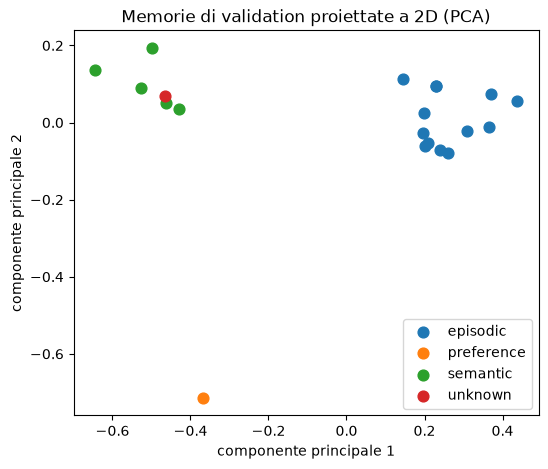

In [5]:
pca = PCA(n_components=2, random_state=42)
proiezione = pca.fit_transform(vettori_val)
print('varianza spiegata dalle prime 2 componenti:',
      np.round(pca.explained_variance_ratio_, 3),
      '-> totale', f'{pca.explained_variance_ratio_.sum():.1%}')

tipi_val = memorie['val']['type'].to_numpy()
colori = {'episodic': 'tab:blue', 'preference': 'tab:orange',
          'semantic': 'tab:green', 'unknown': 'tab:red'}

fig, ax = plt.subplots(figsize=(6, 5))
for tipo in classi:
    mask = tipi_val == tipo
    ax.scatter(proiezione[mask, 0], proiezione[mask, 1],
               label=tipo, color=colori[tipo], s=60)
ax.set_xlabel('componente principale 1')
ax.set_ylabel('componente principale 2')
ax.set_title('Memorie di validation proiettate a 2D (PCA)')
ax.legend()
plt.show()

Guarda il grafico onestamente, non con l'occhio che vuole vedere gruppi
dove non ci sono. Con `explained_variance_ratio_` alto (nell'esecuzione di
riferimento, circa il 98% catturato dalle prime 2 componenti) il grafico
e' un riassunto fedele dello spazio a 16 dimensioni, non una distorsione —
un caso fortunato per questo dataset piccolo e a 4 classi, non una
garanzia generale: con embedding piu' grandi o dati piu' vari la varianza
si spalma su piu' componenti e una proiezione 2D racconta molto meno.

## Cosa hai imparato

- Un embedding ad alta dimensionalita' va **proiettato** per essere
  visualizzato; ogni proiezione butta via informazione, e quanto ne butta
  via dipende dal metodo.
- La **PCA** e' lineare, deterministica, e dichiara onestamente quanta
  varianza ha catturato (`explained_variance_ratio_`) — un numero che va
  sempre letto insieme al grafico, non dopo.
- **UMAP** e' non lineare e ottimizzata per la struttura locale: produce
  grappoli visivamente piu' netti, ma non preserva le distanze globali
  tra grappoli con la stessa affidabilita' della PCA, ed e' stocastica.
- Un vincolo reale dell'ambiente (nessuna versione compatibile di
  `umap-learn` per Python 3.11 in questa sessione) e' un motivo legittimo
  per limitare il codice eseguibile alla PCA, documentando la scelta
  invece di nasconderla o di inventare output mai prodotti.

## Quiz

1. Perche' `explained_variance_ratio_` e' un'informazione da leggere
   *insieme* al grafico PCA, non un dettaglio a margine?
2. In cosa differisce concettualmente cio' che PCA e UMAP cercano di
   preservare quando riducono la dimensionalita'?
3. Due grappoli distanti in un grafico UMAP: cosa puoi concludere con
   sicurezza, e cosa no?

<details>
<summary><b>Apri le risposte</b></summary>

1. Perche' un grafico 2D con `explained_variance_ratio_` basso (per
   esempio 30%) puo' comunque mostrare punti vicini o lontani, ma quella
   vicinanza/lontananza riflette solo una piccola parte della struttura
   reale a piu' dimensioni: il grafico da solo, senza quel numero, non
   dice se ti puoi fidare di quello che vedi.
2. La PCA massimizza la varianza **globale** catturata lungo poche
   direzioni lineari; UMAP preserva le relazioni di **vicinato locale**
   (chi e' vicino a chi nello spazio originale), un obiettivo diverso e
   non lineare.
3. Puoi concludere che i punti nei due grappoli non sono reciprocamente
   tra i vicini piu' prossimi nello spazio originale (questo e' cio' che
   UMAP prova a preservare). Non puoi concludere quanto sono "distanti in
   assoluto" i due grappoli: UMAP non garantisce che le distanze globali
   nel grafico riflettano le distanze reali nello spazio ad alta
   dimensionalita'.
</details>

## Fonti

- scikit-learn, `PCA`:
  https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
- scikit-learn, *Decomposing signals in components (PCA)*:
  https://scikit-learn.org/stable/modules/decomposition.html#pca
- UMAP, *documentazione ufficiale* (citata per contesto teorico; il
  pacchetto non e' installato in questo ambiente, vedi nota sopra):
  https://umap-learn.readthedocs.io/en/latest/how_umap_works.html

## Prossima lezione

Vedere i grappoli a occhio e' un primo passo; la prossima lezione li rende
**operativi** con il clustering (`KMeans`), confrontando le assegnazioni
automatiche con le etichette vere di `type`.